In [51]:
import numpy as np
import matplotlib.pyplot as plt
L=1
ng=50
x0=0
v0=0
q=-1
dx=L/ng
V_L=1000
t=0
dt=0.001
t_tot=1
A=np.zeros((int(ng-2),int(ng-2)))
for i in range(0,ng-2):
    for j in range(0,ng-2):
        if i==j:
            A[i][j]=-2
        elif i==j-1 or i==j+1:
            A[i][j]=1
        else:
            A[i][j]=0

In [52]:
def setrho(x_curr):
    rho=np.zeros(int(ng))
    for i in range(0,ng-1):
        if x_curr>=i*dx and x_curr<(i+1)*dx:
            rho[i]=(((i+1)*dx-x_curr)/dx)*q
            rho[i+1]=((x_curr-i*dx)/dx)*q
            break
        else:
            rho[i]=0
    return rho

In [53]:
def field(rho_curr):
    phi=np.zeros(int(ng))
    phi[0]=0
    phi[ng-1]=V_L
    b=-rho_curr*dx**2
    b[ng-2]=b[ng-2]-V_L
    phi[1:ng-1]=np.linalg.solve(A,b[1:ng-1])
    E=np.zeros(int(ng))
    for i in range(0,ng-2):
        E[i+1]=-(phi[i+2]-phi[i])/(2*dx)
    E[0] = -(phi[1] - phi[0])/dx
    E[ng-1] = -(phi[ng-1] - phi[ng-2])/dx
    return E

In [54]:
for i in range(0,ng):
    if x0>=i*dx and x0<(i+1)*dx:
        rho_j=setrho(x0)
        E_j=field(rho_j)
        E_curr=(((i+1)*dx-x0)/dx)*E_j[i]+((x0-i*dx)/dx)*E_j[i+1]
        break
v_minus=v0-(q*E_curr*dt/2)
x_his, tx_his=[],[]
v_his, tv_his=[],[]
x_his.append(x0)
v_his.append(v_minus)
tx_his.append(0)
tv_his.append(-dt/2)
phi_his=[]


x=x0
v=v_minus
while t < t_tot:

    rho_j = np.zeros(ng)
    E_j = field(rho_j)
    E_curr = 0.0
    for i in range(ng-1):
        if x >= i*dx and x < (i+1)*dx:
            E_curr = (((i+1)*dx-x)/dx)*E_j[i] + ((x-i*dx)/dx)*E_j[i+1]
            break

    v = v + q*E_curr*dt

    x = x + v*dt
    if x <= 0:
        x = 0
        v = -v
    if x >= L:
        x = L
        v = -v
    x_his.append(x)
    tx_his.append(t + dt)

    v_his.append(v)
    tv_his.append(t + dt/2)
    t += dt


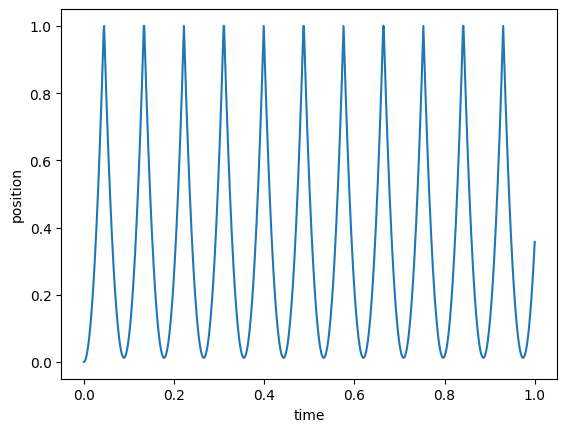

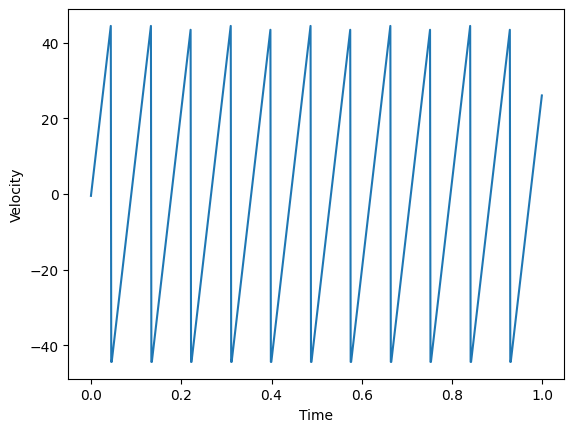

In [55]:
plt.plot(tx_his,x_his)
plt.xlabel('time')
plt.ylabel('position')
plt.show()

plt.plot(tv_his,v_his)
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.show()

#also have to plot potential vs position
